# 01 — Simulate the funnel

Generate a synthetic A/B experiment on a Noon-style marketplace funnel with **known ground truth**. The output of this notebook is the source of every downstream analysis in this repo.

**Hypothesis under test:** showing a free-shipping threshold message on the cart page increases overall completion (purchase) rate by at least 2 percentage points.

**Funnel stages:** impression → product_view → add_to_cart → checkout_start → payment → completion. Conditional rates live in `data/external/funnel_baseline.json`.

**Treatment mechanism:** the treatment arm receives an additional Bernoulli rescue draw so the marginal completion probability rises by exactly `true_lift_pp` percentage points in expectation. Rescued users have all upstream stages flipped True so the event log stays internally consistent.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from dataclasses import asdict

from src import config
from src.simulate import generate_experiment, summarize
from src.io_utils import save_events, save_manifest
from src.viz import funnel_plot

FIG_DIR = ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Parameters

In [2]:
N_USERS = config.DEFAULT_N_USERS
LIFT_PP = config.DEFAULT_TRUE_LIFT_PP
SEED = config.SEED

print(f'n_users:     {N_USERS:,}')
print(f'true lift:   {LIFT_PP} pp')
print(f'seed:        {SEED}')
print(f'analytical baseline completion rate (control): {config.baseline_completion_rate():.4f}')

n_users:     50,000
true lift:   2.5 pp
seed:        42
analytical baseline completion rate (control): 0.0500


## Generate

In [3]:
events, truth = generate_experiment(n_users=N_USERS, lift_pp=LIFT_PP, seed=SEED)
events.head()

,user_id,arm,is_returning,is_mobile,high_aov,impression,product_view,add_to_cart,checkout_start,payment,completion,aov_aed,items_per_order,page_load_ms,refunded,cart_abandoned
0,1,treatment,False,False,False,True,False,False,False,False,False,NaN,NaN,1818.319165,False,False
1,2,control,True,False,False,True,False,False,False,False,False,NaN,NaN,1748.773613,False,False
2,3,treatment,False,True,False,True,False,False,False,False,False,NaN,NaN,1844.046082,False,False
3,4,treatment,True,True,False,True,False,False,False,False,False,NaN,NaN,1911.427586,False,False
4,5,control,False,False,False,True,False,False,False,False,False,NaN,NaN,1991.927277,False,False


## Per-arm summary

In [4]:
summary = summarize(events)
summary

,arm,n,product_views,add_to_carts,checkout_starts,payments,completions,mean_aov,mean_items,mean_page_load_ms,refund_rate,completion_rate
0,control,24814,8569,2951,1968,1459,1220,286.174351,2.478689,1849.315680,0.001491,0.049166
1,treatment,25186,9335,3678,2689,2167,1940,281.958278,2.537113,1849.509123,0.003375,0.077027


In [5]:
control_rate = summary.loc[summary.arm == 'control', 'completion_rate'].iloc[0]
treatment_rate = summary.loc[summary.arm == 'treatment', 'completion_rate'].iloc[0]
observed_lift_pp = (treatment_rate - control_rate) * 100

print(f'control completion rate:    {control_rate:.4f}')
print(f'treatment completion rate:  {treatment_rate:.4f}')
print(f'observed lift:              {observed_lift_pp:+.3f} pp')
print(f'true lift (ground truth):   {truth.true_lift_pp:+.3f} pp')

control completion rate:    0.0492
treatment completion rate:  0.0770
observed lift:              +2.786 pp
true lift (ground truth):   +2.500 pp


## Funnel chart

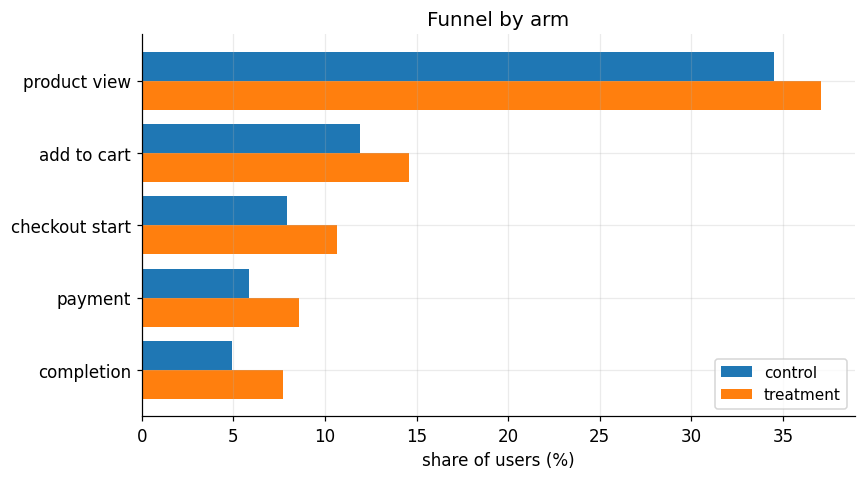

In [6]:
_ = funnel_plot(summary, save_to=FIG_DIR / '01_funnel_drop.png')

## Save outputs

In [7]:
config.PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
save_events(events, config.EXPERIMENT_EVENTS_PARQUET)
summary.to_csv(config.EXPERIMENT_SUMMARY_CSV, index=False)
save_manifest(asdict(truth), config.GROUND_TRUTH_JSON)

print(f'wrote: {config.EXPERIMENT_EVENTS_PARQUET.name}, {config.EXPERIMENT_SUMMARY_CSV.name}, {config.GROUND_TRUTH_JSON.name}')
print(f'into:  {config.PROCESSED_DIR.name}/')

wrote: experiment_events.parquet, experiment_summary.csv, ground_truth.json
into:  processed/


## Sanity checks

In [8]:
# No completion without payment (funnel monotonicity)
assert (events.loc[events.completion, 'payment']).all(), 'completion without payment found'
assert (events.loc[events.payment, 'checkout_start']).all(), 'payment without checkout_start'
assert (events.loc[events.checkout_start, 'add_to_cart']).all(), 'checkout without add_to_cart'

# Secondary metrics only populated for completers
assert events.loc[~events.completion, 'aov_aed'].isna().all()
assert events.loc[events.completion, 'aov_aed'].notna().all()

# Arm split roughly balanced
share_control = (events.arm == 'control').mean()
assert 0.49 <= share_control <= 0.51, f'arm split drifted: {share_control:.4f}'

print('all sanity checks passed')

all sanity checks passed
